In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta

In [5]:
# Load dataset from CSV file into a pandas DataFrame.
from pathlib import Path

DATA_DIR = Path("../data")

orders_df = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
)

payments_df = pd.read_csv(
    DATA_DIR / "olist_order_payments_dataset.csv"
)

customers_df = pd.read_csv(
    DATA_DIR / "olist_customers_dataset.csv"
)

## Business Question

How can we identify valuable customer segments based on how recently, how often, and how much customers purchase?

## Why This Matters

RFM analysis helps the business separate high-value customers from inactive customers. This can support targeted marketing, retention campaigns, and customer loyalty strategies.

In [6]:
# Keep only delivered orders because RFM should be based on completed purchases.
delivered_orders_df = orders_df[
    orders_df["order_status"] == "delivered"
].copy()

# Aggregate payment value at the order level.
# Some orders may have multiple payment records, so we sum payment_value by order_id.
order_value_df = (
    payments_df
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

# Merge delivered orders with total order value and customer unique ID.
# customer_unique_id is used because the same customer can have multiple customer_id values.
rfm_base_df = (
    delivered_orders_df
    .merge(order_value_df, on="order_id", how="left")
    .merge(
        customers_df[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)

# Preview the RFM base table.
rfm_base_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,72632f0f9dd73dfee390c9b22eb56dd6


In [7]:
# Check the size of the final RFM base table.
rfm_base_df.shape

(96478, 10)

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
payment_value                     1
customer_unique_id                0
dtype: int64

## Data Quality Check

Before calculating RFM metrics, we verify missing values created during filtering and merging.

Understanding missing data helps ensure that customer segments are accurate and prevents biased calculations.

In [9]:
# Check missing values after the merge.
rfm_base_df.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
payment_value                     1
customer_unique_id                0
dtype: int64

#### For RFM, we only need:
customer_unique_id
order_purchase_timestamp
payment_value


The missing delivery and approval dates do not affect RFM.
The single missing payment_value should be investigated.

### Key Finding

Most missing values occur in operational delivery fields that are not required for RFM analysis.

Only one transaction had a missing payment amount and was removed to ensure accurate Monetary calculations.

## Business Question

How can we segment customers based on their purchase recency, purchase frequency, and total spending?

## Why This Matters

RFM analysis helps identify high-value customers, customers at risk of churn, and opportunities for targeted retention campaigns.

The three RFM dimensions are:

- Recency: How recently did the customer make a purchase?
- Frequency: How often does the customer purchase?
- Monetary: How much revenue does the customer generate?

In [13]:
# Define the reference date for recency calculations.
snapshot_date = (
    rfm_base_df["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

print(snapshot_date)

2018-08-30 15:00:37


In [14]:
# Calculate Recency, Frequency, and Monetary metrics for each customer.

rfm_df = (
    rfm_base_df
    .groupby("customer_unique_id")
    .agg(
        Recency=(
            "order_purchase_timestamp",
            lambda x: (snapshot_date - x.max()).days
        ),
        Frequency=(
            "order_id",
            "nunique"
        ),
        Monetary=(
            "payment_value",
            "sum"
        )
    )
    .reset_index()
)

In [10]:
# Investigate records with missing monetary values.
rfm_base_df[rfm_base_df["payment_value"].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,customer_unique_id
29811,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00,NaN,830d5b7aaa3b6f1e9ad63703bec97d23


In [11]:
# Remove records with missing payment values because
# Monetary calculations require a valid transaction amount.
rfm_base_df = rfm_base_df.dropna(subset=["payment_value"])

In [12]:
rfm_base_df[["customer_unique_id",
             "order_purchase_timestamp",
             "payment_value"]].isna().sum()

customer_unique_id          0
order_purchase_timestamp    0
payment_value               0
dtype: int64

### Key Finding

Most missing values occur in operational delivery fields that are not required for RFM analysis.

Only one transaction had a missing payment amount and was removed to ensure accurate Monetary calculations.

## Business Question

How can we transform RFM metrics into customer segments that support targeted marketing and retention strategies?

## Why This Matters

Raw RFM values are difficult to interpret at scale. Scoring customers allows us to classify them into meaningful groups such as Champions, Loyal Customers, and At-Risk Customers.

In [17]:
# Review the distribution of RFM metrics before scoring customers.
# The metrics are on different scales, so we need to standardize them.
rfm_df.describe().round(2)

,Recency,Frequency,Monetary
count,93357.00,93357.00,93357.00
mean,237.94,1.03,165.20
std,152.58,0.21,226.31
min,1.00,1.00,9.59
25%,114.00,1.00,63.06
50%,219.00,1.00,107.78
75%,346.00,1.00,182.56
max,695.00,15.00,13664.08


In [18]:
# Assign Recency scores using quintiles.
# Lower Recency values are better because recent customers are more engaged.
# Labels are reversed so the most recent customers receive the highest score.

rfm_df["R_Score"] = pd.qcut(
    rfm_df["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

In [19]:
# Assign Frequency scores using quintiles.
# Higher Frequency values are better because repeat customers are more valuable.
# rank(method="first") prevents duplicate bin edge errors caused by tied values.

rfm_df["F_Score"] = pd.qcut(
    rfm_df["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [20]:
# Assign Monetary scores using quintiles.
# Higher Monetary values indicate customers who generate more revenue.

rfm_df["M_Score"] = pd.qcut(
    rfm_df["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

In [21]:
# Convert score columns from categorical objects to integers
# to enable mathematical operations and segmentation.

score_cols = ["R_Score", "F_Score", "M_Score"]

rfm_df[score_cols] = rfm_df[score_cols].astype(int)

In [22]:
# Combine the individual RFM scores into a single three-digit code.
# Example:
# 555 = recent, frequent, high-spending customer
# 111 = inactive, infrequent, low-spending customer

rfm_df["RFM_Score"] = (
    rfm_df["R_Score"].astype(str)
    + rfm_df["F_Score"].astype(str)
    + rfm_df["M_Score"].astype(str)
)

In [23]:
# Preview the scored customer dataset.

rfm_df.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


## Customer Scoring

To make RFM metrics easier to interpret, customers are assigned scores from 1 to 5 based on quintiles.

- Recency: Lower values receive higher scores.
- Frequency: Higher values receive higher scores.
- Monetary: Higher values receive higher scores.

The combined RFM score creates a standardized customer profile that supports segmentation and targeted business actions.

## Business Question

Which customer segments contribute the most value, and which customers are at risk of churn?

## Why This Matters

Customer segmentation enables targeted marketing strategies by identifying:

- High-value customers to retain and reward
- Promising customers to nurture
- At-risk customers to re-engage
- Inactive customers who may require win-back campaigns

In [29]:
# Create customer segments using RFM scores.
def segment_customers(row):

    if (
        row["R_Score"] >= 4
        and row["F_Score"] >= 4
        and row["M_Score"] >= 4
    ):
        return "Champions"

    elif (
        row["R_Score"] >= 3
        and row["F_Score"] >= 3
        and row["M_Score"] >= 3
    ):
        return "Loyal Customers"

    elif (
        row["R_Score"] >= 4
        and row["F_Score"] <= 3
    ):
        return "Potential Loyalists"

    elif (
        row["R_Score"] <= 2
        and row["F_Score"] >= 3
    ):
        return "At Risk"

    else:
        return "Lost Customers"

In [30]:
# Assign each customer to an RFM segment.

rfm_df["Segment"] = rfm_df.apply(
    segment_customers,
    axis=1
)

In [ ]:
# Calculate segment counts and percentages.

segment_summary_df = (
    rfm_df["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary_df.columns = [
    "Segment",
    "Customer_Count"
]

segment_summary_df["Percentage"] = (
    segment_summary_df["Customer_Count"]
    / segment_summary_df["Customer_Count"].sum()
    * 100
).round(2)

In [27]:
# Calculate the percentage of customers in each segment.

segment_summary_df["Percentage"] = (
    segment_summary_df["Customer_Count"]
    / segment_summary_df["Customer_Count"].sum()
    * 100
).round(2)

segment_summary_df

,Segment,Customer_Count,Percentage
0,Lost Customers,22359,23.95
1,At Risk,22229,23.81
2,Loyal Customers,18824,20.16
3,Potential Loyalists,14984,16.05
4,Champions,14961,16.03


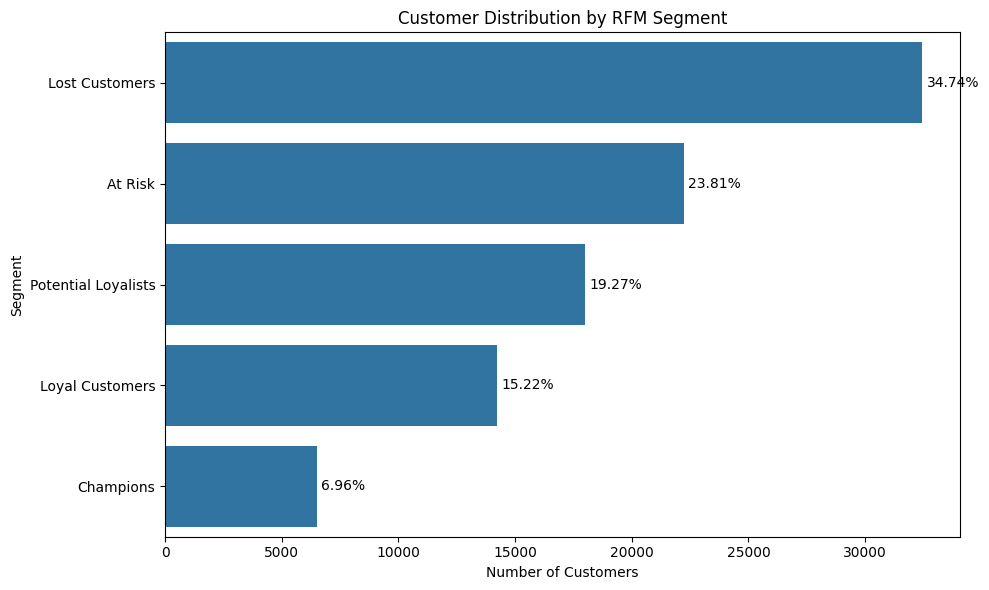

In [33]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=segment_summary_df,
    x="Customer_Count",
    y="Segment"
)

for i, row in segment_summary_df.iterrows():
    ax.text(
        row["Customer_Count"] + 200,
        i,
        f'{row["Percentage"]}%',
        va="center"
    )

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

## Key Findings

- Lost Customers represent the largest segment, accounting for 34.74% of the customer base.
- At Risk customers account for 23.81%, indicating a substantial churn prevention opportunity.
- Champions represent only 6.96% of customers but are expected to contribute a disproportionate share of revenue.
- Potential Loyalists account for 19.27% and should be targeted with personalized campaigns to increase repeat purchases.
- Loyal Customers represent 15.22% of customers and should be retained through loyalty programs and cross-selling initiatives.

Overall, approximately 59% of customers are either Lost or At Risk, highlighting the importance of customer retention strategies.

## Business Question

How much revenue does each customer segment generate?

In [34]:
# Aggregate customer metrics by segment.

segment_metrics_df = (
    rfm_df
    .groupby("Segment")
    .agg(
        Customers=("customer_unique_id", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Total_Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean")
    )
    .round(2)
    .sort_values(
        by="Total_Revenue",
        ascending=False
    )
)

segment_metrics_df

,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Revenue
Segment,,,,,
Lost Customers,32435,278.82,1.00,4129301.53,127.31
At Risk,22229,394.65,1.05,3711784.17,166.98
Loyal Customers,14209,153.23,1.05,2943315.48,207.14
Potential Loyalists,17991,90.49,1.00,2611403.75,145.15
Champions,6493,91.11,1.18,2026656.84,312.13


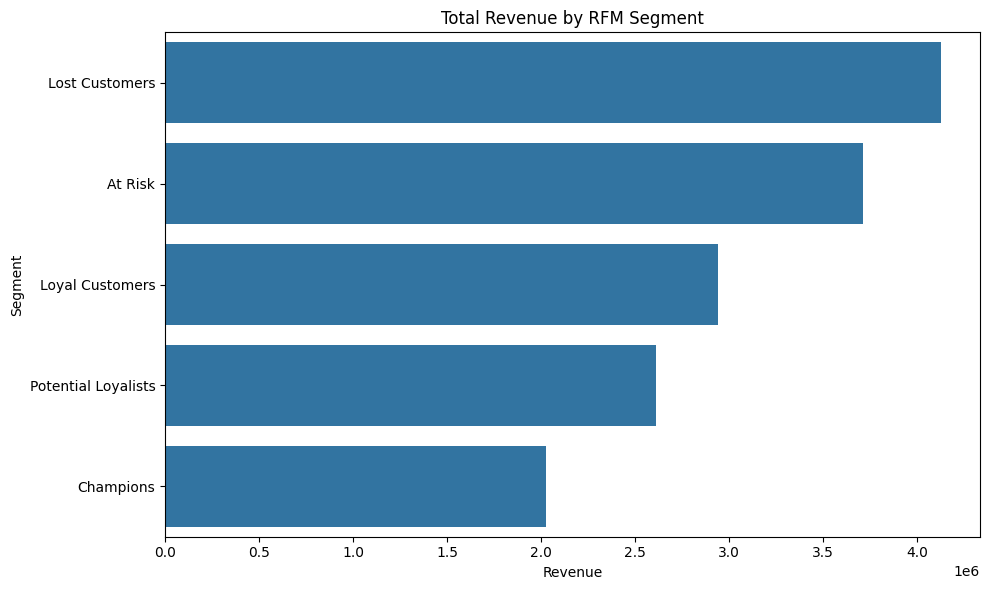

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_metrics_df.reset_index(),
    x="Total_Revenue",
    y="Segment"
)

plt.title("Total Revenue by RFM Segment")
plt.xlabel("Revenue")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

In [36]:
# Calculate each segment's share of total revenue.

segment_metrics_df["Revenue_Share_Pct"] = (
    segment_metrics_df["Total_Revenue"]
    / segment_metrics_df["Total_Revenue"].sum()
    * 100
).round(2)

segment_metrics_df

,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Revenue,Revenue_Share_Pct
Segment,,,,,,
Lost Customers,32435,278.82,1.00,4129301.53,127.31,26.77
At Risk,22229,394.65,1.05,3711784.17,166.98,24.07
Loyal Customers,14209,153.23,1.05,2943315.48,207.14,19.08
Potential Loyalists,17991,90.49,1.00,2611403.75,145.15,16.93
Champions,6493,91.11,1.18,2026656.84,312.13,13.14


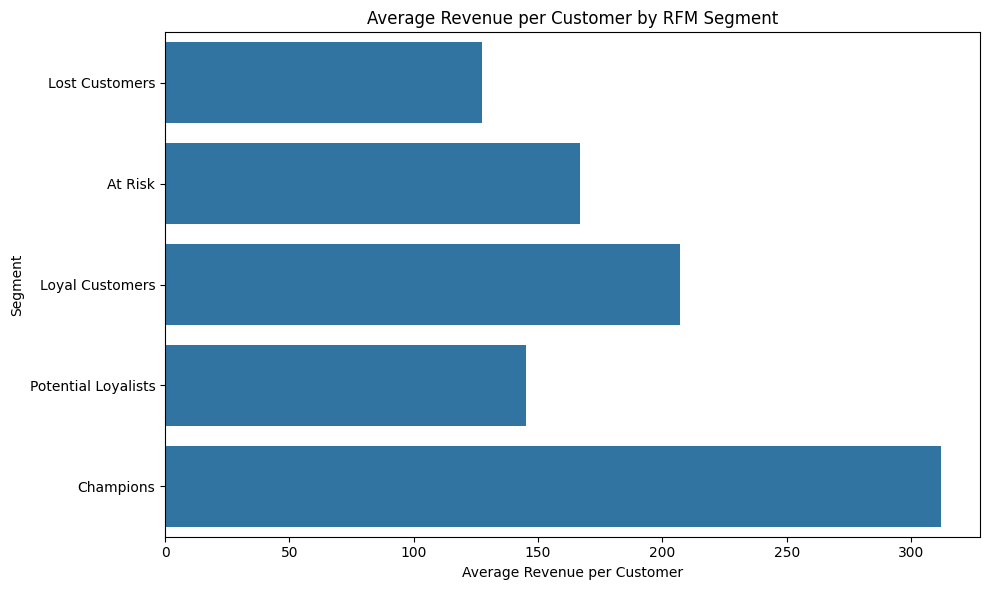

In [37]:
# Compare average customer value across segments.

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_metrics_df.reset_index(),
    x="Avg_Revenue",
    y="Segment"
)

plt.title("Average Revenue per Customer by RFM Segment")
plt.xlabel("Average Revenue per Customer")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

## Key Findings

- Champions generate the highest average revenue per customer, indicating they are the most valuable customer segment.
- Although Lost Customers contribute the highest total revenue, this is primarily driven by their large population size rather than high individual customer value.
- Loyal Customers demonstrate strong repeat purchasing behavior and represent a key segment for cross-selling and retention initiatives.
- Potential Loyalists present an opportunity for targeted campaigns designed to increase purchase frequency and lifetime value.
- At-Risk customers should be prioritized for re-engagement campaigns to prevent future revenue loss.

Comparing total revenue with average revenue per customer provides a more complete understanding of customer value and helps prioritize marketing investments.

# Conclusion

The RFM analysis revealed that customers contribute value to the business in different ways.

Champions generated the highest average revenue per customer and represent the most valuable customer segment. Loyal Customers demonstrated strong purchasing behavior and provide opportunities for retention and cross-selling initiatives. Potential Loyalists represent a growth opportunity because they have already shown engagement with the business and may increase their value through targeted marketing efforts.

Although Lost Customers generated the highest total revenue, this was largely driven by the size of the segment rather than the value of individual customers. This highlights the importance of evaluating both total revenue and customer-level value when making business decisions.

Overall, the analysis demonstrates that customer value is not evenly distributed across the customer base and that different segments require different engagement strategies.

# Executive Summary

The purpose of this analysis was to understand customer behavior using the Recency, Frequency, and Monetary (RFM) framework and identify opportunities to improve customer retention and revenue growth.

During the analysis, I found that Champions and Loyal Customers represent the most strategically important customer groups because they generate strong revenue and demonstrate higher engagement with the business. I also identified segments that may require intervention, including At-Risk and Lost Customers, where targeted retention efforts could help reduce future revenue loss.

The results show that customer value is highly concentrated and that treating all customers the same would likely lead to inefficient marketing investment. By segmenting customers according to their purchasing behavior, the business can create more targeted retention, re-engagement, and growth strategies.

# Management Recommendations

1. Prioritize retention efforts for Champions and Loyal Customers.
2. Develop re-engagement campaigns for At-Risk customers before they become inactive.
3. Create targeted promotions for Potential Loyalists to increase purchase frequency.
4. Monitor Lost Customers and evaluate win-back campaigns for high-value accounts.
5. Use RFM segmentation to personalize future marketing and customer relationship strategies.
